# Which *sites* to mutate: greedy selection for a homodimer (BmrA)

`labelizer_greedy_pipeline.ipynb` asks, for a monomer, which FRET pairs to
measure. A homo-oligomer asks a different question, and answering the monomer
question instead quietly buys the wrong experiment.

In a homo-oligomer the labelling mix is **statistical**. Every protomer carries
the same sequence, so a cysteine introduced at site 1 exists on *all* protomers
at once, and donor and acceptor end up in every combination the chosen sites
allow. Each site is paid for **once**, as one mutation, and the pairs it makes
come with it: a dimer labelled at sites 1 and 2 carries 1:1 and 2:2 across the
interface, 1--2 within each protomer, and 1--2 across it. So the thing worth
choosing is a **set of sites**, and the thing worth scoring is the **set of
distances that set implies** — all of them, not any single one.

`IMP.bff.select_probe_positions` does exactly that. It applies Olga's criterion
(Dimura *et al.*, *Nat. Commun.* **11**, 5394, 2020) per *site*: each greedy
step scores a candidate by the expected RMSD left over when every distance the
enlarged site set implies has been measured. `select_probe_pairs`, which adds
one pair per step, is the monomer selector — there a pair really is a double
mutant, and pairs are the unit you buy. Both are run below on the same data,
and the difference between them is the point.

**What this notebook runs on.** BmrA is the multidrug ABC transporter of
*Bacillus subtilis*: a real homodimer, with two experimentally determined
states in the PDB.

* **6R72** — nucleotide-binding domains closed (outward-facing), the E504A
  mutant with ATP and Mg, X-ray. The entry holds two copies of the dimer;
  only chains A and B are used, because pairing a chain of one copy with a
  chain of the other measures crystal packing, not the protein.
* **8QOE** — nucleotide-binding domains open (inward-facing), cryo-EM,
  chains A and B.

An earlier version of this notebook built a *synthetic* C2 dimer out of T4
lysozyme and perturbed it at random to make the alternatives the selection had
to tell apart. Nothing about that ensemble was measured, so nothing about the
answer could be checked. Here the alternatives are the two deposited states and
the assemblies between them, and every distance is computed on coordinates
somebody determined.

In [1]:
%matplotlib inline
import itertools, json, pathlib, sys, tempfile, time

import numpy as np
import matplotlib.pyplot as plt

import IMP
import IMP.atom
import IMP.core
import IMP.algebra
import IMP.bff as bff

# workshop.py fetches and cuts the two BmrA entries; it lives in doc/workshop/.
for _root in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_root / "doc" / "workshop" / "workshop.py").exists():
        sys.path.insert(0, str(_root / "doc" / "workshop"))
        break
else:
    raise RuntimeError("doc/workshop/workshop.py not found above the working directory")
import workshop as ws

GRID = 1.0        # accessible-volume grid spacing, Angstrom
N_SITES = 10      # candidate sites carried into the selection
MIN_LS = 1.5      # label score a candidate must reach, on every chain of both states
MIN_SEP = 25      # minimum separation in sequence between candidates
N_FRAMES = 21     # assemblies in the ensemble, closed to open
ERR = 0.06        # measurement error, in transfer efficiency
R0 = 52.0         # Forster radius of the dye pair, Angstrom

WORK = pathlib.Path(tempfile.mkdtemp(prefix="bmra_greedy_"))
print("IMP.bff", bff.get_module_version(), "| scratch", WORK)

IMP.bff ab5de21 | scratch /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/bmra_greedy_mmyi7ja3


## 1. Two states, and the assemblies between them

The two entries do not contain the same atoms: the X-ray model is missing
loops the cryo-EM model resolves and the reverse, and the cryo-EM model carries
hydrogens. Everything below moves one atom set around, so the first step keeps
only the heavy atoms both entries agree on — same chain, same residue number,
same residue name, same atom name — and superposes the open state onto the
closed one.

The ensemble is then the straight line between them: frame 0 is the closed
dimer, the last frame is the open dimer, and the frames in between interpolate
each atom. That line is **not a mechanism**. No claim is made that BmrA passes
through these assemblies, and the ATP and Mg of 6R72 are dropped, because the
open entry has none and the frames have to share one atom set. What the line
is good for is a ruler: it gives the selector a graded family of assemblies
that differ only in how far the transition has gone, so "how well would this
experiment tell them apart" is a question with an answer.

In [2]:
def heavy_atoms(path):
    """{(chain, resi, atom): (resname, xyz, line)} for the first altloc of each atom."""
    out = {}
    for line in open(path):
        if not line.startswith("ATOM") or line[16] not in (" ", "A"):
            continue
        key = (line[21], int(line[22:26]), line[12:16].strip())
        if key not in out:
            out[key] = (line[17:20].strip(),
                        (float(line[30:38]), float(line[38:46]), float(line[46:54])),
                        line)
    return out


closed_raw = heavy_atoms(ws.single_dimer("closed"))
open_raw = heavy_atoms(ws.single_dimer("open"))
shared = sorted((k for k in closed_raw if k in open_raw and open_raw[k][0] == closed_raw[k][0]),
                key=lambda k: (k[0], k[1]))

Xc = np.array([closed_raw[k][1] for k in shared])
Xo = np.array([open_raw[k][1] for k in shared])
c_open, c_closed = Xo.mean(0), Xc.mean(0)
U, _, Vt = np.linalg.svd((Xo - c_open).T @ (Xc - c_closed))
rotation = Vt.T @ np.diag([1, 1, np.sign(np.linalg.det(Vt.T @ U.T))]) @ U.T
Xo = (rotation @ (Xo - c_open).T).T + c_closed
transition = float(np.sqrt(((Xo - Xc) ** 2).sum(1).mean()))


def write_pdb(path, X):
    rows = [closed_raw[k][2][:6] + f"{n % 100000:5d}" + closed_raw[k][2][11:30]
            + f"{x[0]:8.3f}{x[1]:8.3f}{x[2]:8.3f}" + closed_raw[k][2][54:66] + "\n"
            for n, (k, x) in enumerate(zip(shared, X), start=1)]
    pathlib.Path(path).write_text("".join(rows) + "END\n")
    return pathlib.Path(path)


pdb_closed = write_pdb(WORK / "BmrA_closed.pdb", Xc)
pdb_open = write_pdb(WORK / "BmrA_open.pdb", Xo)
frac = np.linspace(0.0, 1.0, N_FRAMES)

residues = sorted(set(k[1] for k in shared if k[0] == "A"))
print(f"6R72 (closed) {len(closed_raw)} heavy atoms, 8QOE (open) {len(open_raw)}; "
      f"{len(shared)} shared by both, {len(residues)} residues per protomer")
print(f"closed -> open after superposition: {transition:.2f} A RMSD over the shared atoms")
print(f"ensemble: {N_FRAMES} assemblies, {transition / (N_FRAMES - 1):.2f} A RMSD apart")

6R72 (closed) 8788 heavy atoms, 8QOE (open) 17816; 8609 shared by both, 558 residues per protomer
closed -> open after superposition: 11.05 A RMSD over the shared atoms
ensemble: 21 assemblies, 0.55 A RMSD apart


## 2. The label score, and the term that is missing

The label score (Dimura *et al.*) ranks residues by how well they would take a
dye. It multiplies likelihood ratios for solvent exposure, resemblance to a
cysteine, secondary structure, proximity to a tryptophan, local charge — and
evolutionary conservation.

**For BmrA there is no conservation.** UniProt O06967 carries no per-residue
conservation track and no ConSurf cross-reference; ConSurf-DB was unreachable
when this was checked; and labelizer.org, which computes ConSurf grades
server-side, returns a header-only table for 6R72 and 8QOE, so the grades are
not there either. This was checked on 2026-09-07 and the detail, including the
route through labelizer.org and why it fails, is written down in
`prototypes/bmra/bmra/conservation.py`.

Because the terms *multiply*, running the published model unchanged on a
structure with no grades does not give a slightly worse ranking; it gives zero
for every residue, which the cell below prints. So the model is rebuilt without
the `cs` term.

What that costs is real and worth stating: the remaining terms are all local
geometry and chemistry. They know that a residue is exposed, unstructured and
not next to a tryptophan; they do not know that it is the catalytic glutamate
of the Walker B motif. Conservation is the term that would have kept the
ranking away from functionally important residues, and without it that has to
be done by reading the annotation of whatever the selection returns.

In [3]:
model = bff.LabelizerParameterList()
for parameter in bff.labelizer_model_paper():
    if parameter.tag != "cs":
        model.append(parameter)
print("paper model terms :", [p.tag for p in bff.labelizer_model_paper()])
print("terms used here   :", [p.tag for p in model])

paper = bff.labelizer_score_structure(str(pdb_closed), bff.labelizer_model_paper(),
                                      bff.LabelizerOptions(), "")
paper_combined = np.array([r.value for r in paper if r.score_type == "combined"])
print(f"\npaper model, no ConSurf grades supplied: combined score "
      f"{paper_combined.min():.2f} to {paper_combined.max():.2f} over "
      f"{len(paper_combined)} residues -- the cs term is zero and it multiplies")


def label_scores(path):
    rows = bff.labelizer_score_structure(str(path), model, bff.LabelizerOptions(), "")
    return ({(r.asym_id, r.seq_id): r.value for r in rows if r.score_type == "combined"},
            {(r.asym_id, r.seq_id): r.comp_id for r in rows if r.score_type == "combined"})


ls_closed, resname = label_scores(pdb_closed)
ls_open, _ = label_scores(pdb_open)
values = np.array(list(ls_closed.values()))
print(f"without cs: combined score {values.min():.2f} to {values.max():.2f}, "
      f"mean {values.mean():.2f} over {len(values)} residues")

paper model terms : ['cs', 'se', 'tp', 'cr', 'ss', 'ce']
terms used here   : ['se', 'tp', 'cr', 'ss', 'ce']

paper model, no ConSurf grades supplied: combined score 0.00 to 0.00 over 1116 residues -- the cs term is zero and it multiplies
without cs: combined score 0.00 to 1.90, mean 1.04 over 1116 residues


### The two protomers have to agree

Chains A and B are the same sequence in the same fold, and the label score is a
property of one protomer, so the score of residue *i* on chain A and on chain B
should be the same number. Checking that is free, and it checks two things at
once: that the dimer was cut correctly, and that the score is reading the local
environment rather than something accidental about one chain.

Most residues agree exactly. The ones that do not are residues the two chains
model differently — a side chain resolved in one protomer and not the other, a
loop in a different rotamer — and they are worth knowing about *before*
mutating, because a mutation there will not behave the same on both protomers.
A score of exactly zero on one chain is the same multiplication as before: one
of the terms went to zero there, usually because the residue is buried in that
protomer, and the product follows.

In [4]:
both = [i for i in residues if ("A", i) in ls_closed and ("B", i) in ls_closed]
gap = np.array([abs(ls_closed[("A", i)] - ls_closed[("B", i)]) for i in both])
print(f"{len(both)} residues scored on both chains of the closed state")
print(f"|score(A) - score(B)|: median {np.median(gap):.3f}, "
      f"{(gap < 0.05).mean() * 100:.0f} % below 0.05, "
      f"{(gap < 0.25).mean() * 100:.0f} % below 0.25, max {gap.max():.2f}")
worst = sorted(both, key=lambda i: -abs(ls_closed[("A", i)] - ls_closed[("B", i)]))[:3]
for i in worst:
    print(f"   {resname[('A', i)]}{i}: A {ls_closed[('A', i)]:.2f}  B {ls_closed[('B', i)]:.2f}")
top = max(both, key=lambda i: ls_closed[("A", i)])
print(f"best-scoring residue {resname[('A', top)]}{top}: "
      f"A {ls_closed[('A', top)]:.2f}, B {ls_closed[('B', top)]:.2f}")

555 residues scored on both chains of the closed state
|score(A) - score(B)|: median 0.000, 62 % below 0.05, 90 % below 0.25, max 1.42
   SER234: A 0.00  B 1.42
   ARG228: A 1.34  B 0.00
   ILE233: A 0.00  B 0.92
best-scoring residue CYS436: A 1.90, B 1.90


### Candidates

A candidate has to clear the threshold **on every chain of both states**. A
residue that is a good site in the closed dimer and a bad one in the open dimer
cannot report on the difference between them, which is the only thing this
experiment is for. Candidates closer together in sequence than `MIN_SEP` are
treated as redundant: they see the same neighbourhood.

The left panel below is the score along the sequence for both protomers; the
right panel is the same residues plotted closed against open, so the sites that
change between the states are the ones off the diagonal.

34 residues score at least 1.5 on every chain of both states
  SER10  LYS11  SER25  SER58  SER60  SER63  GLN66  SER81  SER113  ASN118  SER143  GLN208  SER219  SER235  GLN299  GLU323  GLN333  LYS351  SER361  SER376  SER392  THR394  GLN422  GLU423  SER428  CYS436  GLU463  GLU474  SER508  GLN519  GLU526  LYS551  SER566  GLN577


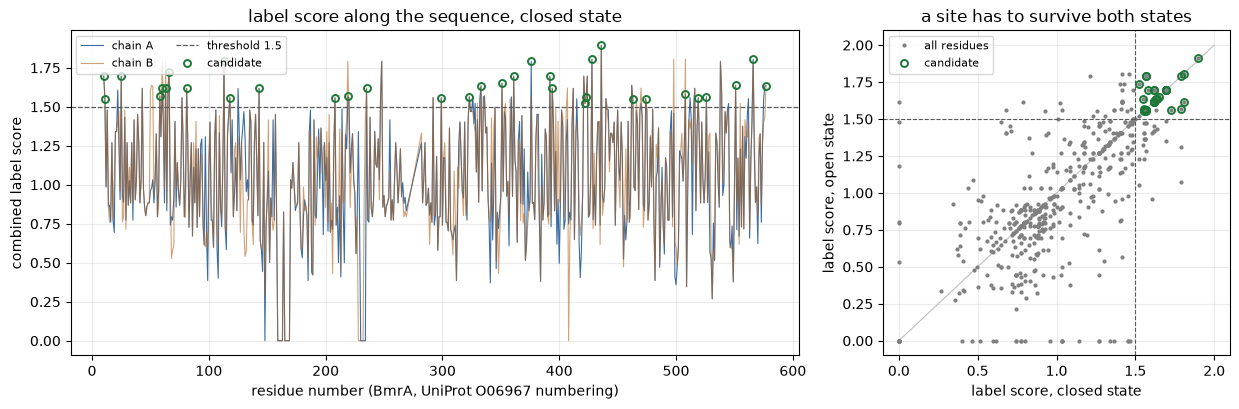

In [5]:
candidates = [i for i in both
              if ("A", i, "CB") in closed_raw and ("B", i, "CB") in closed_raw
              and resname[("A", i)] != "GLY"
              and min(ls_closed[("A", i)], ls_closed[("B", i)],
                      ls_open.get(("A", i), 0.0), ls_open.get(("B", i), 0.0)) >= MIN_LS]
print(f"{len(candidates)} residues score at least {MIN_LS} on every chain of both states")
print("  " + "  ".join(f"{resname[('A', i)]}{i}" for i in candidates))

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12.5, 4.2),
                             gridspec_kw={"width_ratios": [2.1, 1]})
ax.plot(both, [ls_closed[("A", i)] for i in both], lw=0.8, color="#3b6ea5", label="chain A")
ax.plot(both, [ls_closed[("B", i)] for i in both], lw=0.8, color="#b5651d", alpha=0.6,
        label="chain B")
ax.axhline(MIN_LS, color="0.35", ls="--", lw=0.9, label=f"threshold {MIN_LS}")
ax.plot(candidates, [ls_closed[("A", i)] for i in candidates], "o", ms=5,
        mfc="none", mec="#1b7837", mew=1.4, label="candidate")
ax.set_xlabel("residue number (BmrA, UniProt O06967 numbering)")
ax.set_ylabel("combined label score")
ax.set_title("label score along the sequence, closed state")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.25)

cx = [ls_closed[("A", i)] for i in both]
ox = [ls_open.get(("A", i), np.nan) for i in both]
bx.plot([0, 2], [0, 2], color="0.75", lw=0.8)
bx.plot(cx, ox, ".", ms=4, color="0.5", label="all residues")
bx.plot([ls_closed[("A", i)] for i in candidates],
        [ls_open[("A", i)] for i in candidates], "o", ms=5, mfc="none",
        mec="#1b7837", mew=1.4, label="candidate")
bx.axhline(MIN_LS, color="0.35", ls="--", lw=0.8)
bx.axvline(MIN_LS, color="0.35", ls="--", lw=0.8)
bx.set_xlabel("label score, closed state")
bx.set_ylabel("label score, open state")
bx.set_title("a site has to survive both states")
bx.legend(fontsize=8, loc="upper left")
bx.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 3. A score is not a volume

The label score says a residue would tolerate a dye. It does not say the dye
fits. The accessible volume is computed from the structure around the
attachment point, and a site that is open in one assembly can be closed in
another — which is exactly what happens when the nucleotide-binding domains of
a transporter come together.

So every candidate is screened by building its dye volume on **every frame** of
the ensemble, on both protomers, and keeping only the candidates that have a
volume everywhere. A frame where the volume is empty is not a distance of zero;
it is no distance at all, and the efficiency comes back as `nan`.

The screen is run through `ProbeNetworkRestraint`, so the volumes are built by
the same code and the same parameters as the distances later on — a site cannot
pass the screen under one set of settings and fail in the network under
another.

In [6]:
def dye_position(i, chain):
    """One fps.json position: an AV1 with a generic Alexa-type linker geometry."""
    return dict(
        allowed_sphere_radius=5.0, anchor_atoms="", atom_name="CB",
        chain_identifier=chain, chain_weighting=False, contact_volume_thickness=3.0,
        contact_volume_trapped_fraction=0.55, linker_length=20.0, linker_width=4.5,
        min_sphere_volume_fraction=0.125, radius1=3.5,
        residue_name=resname[(chain, i)], residue_seq_number=i,
        simulation_grid_resolution=GRID, simulation_type="AV1",
        strip_mask=f"(resid {i} and not name CA+CB+C+N+O) or "
                   "resname HOH SOL WAT DU CL NA 'Cl-' 'Na+'")


def distance_entry(a, b):
    return {"error_neg": 3.0, "error_pos": 3.0, "distance": 50.0,
            "position1_name": a, "position2_name": b,
            "Forster_radius": R0, "distance_type": "RDAMean"}


def fps_file(name, positions, distances):
    path = WORK / f"{name}.fps.json"
    path.write_text(json.dumps(
        {"Positions": positions, "Distances": distances,
         "χ²": {"planning": {"distances": sorted(distances)}}},
        ensure_ascii=False, indent=1))
    return path


m = IMP.Model()
hierarchy = IMP.atom.read_pdb(str(pdb_closed), m)
particles = [IMP.core.XYZ(p) for p in IMP.atom.get_leaves(hierarchy)]


def sweep(restraint):
    """Predicted efficiencies and coordinates for every assembly in the ensemble."""
    E = np.empty((N_FRAMES, len(restraint.get_pair_names())))
    X = np.empty((N_FRAMES, len(particles), 3))
    for k, t in enumerate(frac):
        frame = (1.0 - t) * Xc + t * Xo
        for particle, x in zip(particles, frame):
            particle.set_coordinates(IMP.algebra.Vector3D(*x))
        E[k] = restraint.get_pair_efficiencies()
        X[k] = frame
    return E, X


positions, distances = {}, {}
for i in candidates:
    positions[f"{i}A"] = dye_position(i, "A")
    positions[f"{i}B"] = dye_position(i, "B")
    distances[f"{i}A-{i}B"] = distance_entry(f"{i}A", f"{i}B")

t0 = time.time()
screen = bff.ProbeNetworkRestraint(hierarchy, str(fps_file("screen", positions, distances)),
                                   score_set="planning")
screen_names = list(screen.get_pair_names())
screen_e, _ = sweep(screen)
alive = np.isfinite(screen_e)
print(f"{2 * len(candidates) * N_FRAMES} accessible volumes on a {GRID} A grid "
      f"in {time.time() - t0:.0f} s\n")

lost = [(int(n.split("A-")[0]), j) for j, n in enumerate(screen_names) if not alive[:, j].all()]
print(f"{len(lost)} candidates lose the volume somewhere along the ensemble:")
for i, j in sorted(lost, key=lambda t: -ls_closed[("A", t[0])]):
    where = np.where(~alive[:, j])[0]
    span = ", ".join(f"{frac[w]:.2f}" for w in where[:4]) + (" ..." if len(where) > 4 else "")
    print(f"   {resname[('A', i)]}{i} (score {ls_closed[('A', i)]:.2f}): "
          f"volume in {alive[:, j].sum():2d}/{N_FRAMES} frames, missing at t = {span}")

usable = [int(n.split("A-")[0]) for j, n in enumerate(screen_names) if alive[:, j].all()]
sites = []
for i in sorted(usable, key=lambda i: -ls_closed[("A", i)]):
    if all(abs(i - j) >= MIN_SEP for j in sites):
        sites.append(i)
    if len(sites) == N_SITES:
        break
sites.sort()
print(f"\n{len(usable)} of {len(candidates)} candidates survive; "
      f"the best {len(sites)} at least {MIN_SEP} apart in sequence:")
print("  " + "  ".join(f"{resname[('A', i)]}{i} {ls_closed[('A', i)]:.2f}" for i in sites))

1428 accessible volumes on a 1.0 A grid in 8 s

9 candidates lose the volume somewhere along the ensemble:
   CYS436 (score 1.90): volume in 20/21 frames, missing at t = 0.00
   SER376 (score 1.79): volume in 18/21 frames, missing at t = 0.00, 0.05, 0.10
   SER60 (score 1.62): volume in 20/21 frames, missing at t = 0.00
   SER508 (score 1.58): volume in 19/21 frames, missing at t = 0.00, 0.05
   SER219 (score 1.57): volume in  0/21 frames, missing at t = 0.00, 0.05, 0.10, 0.15 ...
   GLU423 (score 1.56): volume in 19/21 frames, missing at t = 0.00, 0.05
   GLN208 (score 1.56): volume in 16/21 frames, missing at t = 0.00, 0.05, 0.10, 0.15 ...
   GLU474 (score 1.55): volume in 20/21 frames, missing at t = 0.00
   GLN422 (score 1.52): volume in 11/21 frames, missing at t = 0.00, 0.05, 0.65, 0.70 ...

25 of 34 candidates survive; the best 10 at least 25 apart in sequence:
  SER10 1.70  GLN66 1.72  SER113 1.79  SER143 1.62  SER235 1.62  GLN333 1.63  SER361 1.70  SER392 1.70  SER428 1.81  SE

## 4. What a set of sites implies

Mutate *k* sites on a homodimer and you have 2*k* dye positions, because every
site exists on both protomers. Donor and acceptor find each of the combinations,
and they fall into three kinds:

* **1:1** — site *i* on one protomer, the same site on the other. This is the
  classic single-cysteine dimer measurement, and it is what a *single* mutation
  buys: one distance, for one mutation.
* **within one protomer** — sites *i* and *j* on the same chain.
* **across the protomers** — site *i* on one chain, site *j* on the other.

C2 symmetry collapses the mirror images of these: *i*(A)--*j*(A) and
*i*(B)--*j*(B) are the same measurement seen twice, and so are *i*(A)--*j*(B)
and *j*(A)--*i*(B). That leaves *k* distances of the 1:1 kind and two per pair
of sites, which is **k² distinct distances from k mutations**. All of them are
computed below, mirror images included, and each mirror pair is averaged into
one observable.

Averaging is not a tidying step, it is the model of the experiment: a
statistically labelled sample contains both members of the pair at once and no
measurement separates them. Which makes the spread *within* a mirror pair worth
looking at — it is the symmetry check, in the units the experiment reports, and
where it exceeds the measurement error the two protomers are not equivalent and
the single number is the mean of a population that is really two.

In [7]:
positions, distances, groups = {}, {}, {}
for i in sites:
    positions[f"{i}A"] = dye_position(i, "A")
    positions[f"{i}B"] = dye_position(i, "B")


def register(key, a, b):
    distances[f"{a}-{b}"] = distance_entry(a, b)
    groups.setdefault(key, []).append(f"{a}-{b}")


for a, i in enumerate(sites):
    register((a, a, "1:1"), f"{i}A", f"{i}B")
    for b, j in enumerate(sites):
        if b <= a:
            continue
        register((a, b, "one protomer"), f"{i}A", f"{j}A")
        register((a, b, "one protomer"), f"{i}B", f"{j}B")
        register((a, b, "across"), f"{i}A", f"{j}B")
        register((a, b, "across"), f"{j}A", f"{i}B")

t0 = time.time()
network = bff.ProbeNetworkRestraint(hierarchy, str(fps_file("network", positions, distances)),
                                    score_set="planning")
names = list(network.get_pair_names())
column = {n: k for k, n in enumerate(names)}
efficiencies, coordinates = sweep(network)
rmsds = bff.pairwise_rmsd(coordinates, True)
print(f"{len(positions)} dye positions, {len(names)} distances, {N_FRAMES} assemblies "
      f"in {time.time() - t0:.0f} s; every value finite: {np.isfinite(efficiencies).all()}")

keys = sorted(groups)
observables = np.column_stack([efficiencies[:, [column[n] for n in groups[k]]].mean(1)
                               for k in keys])
pair_sites = np.array([[k[0], k[1]] for k in keys], dtype=np.int32)
mirrored = [k for k, key in enumerate(keys) if len(groups[key]) > 1]
spread_all = np.array([float(np.abs(np.diff(efficiencies[:, [column[n] for n in groups[k]]],
                                            axis=1)).max()) if len(groups[k]) > 1 else 0.0
                       for k in keys])
spread_ends = np.array([float(np.abs(np.diff(efficiencies[[0, -1]][:, [column[n] for n in groups[k]]],
                                             axis=1)).max()) if len(groups[k]) > 1 else 0.0
                        for k in keys])
counts = {kind: sum(1 for k in keys if k[2] == kind) for kind in ("1:1", "one protomer", "across")}
print(f"{len(keys)} observables from {len(names)} distances "
      f"({len(sites)} sites, {len(sites) ** 2} = k^2): " +
      ", ".join(f"{v} {kind}" for kind, v in counts.items()))
print(f"\nC2 check on the two deposited states, |E(A...) - E(B...)|: "
      f"median {np.median(spread_ends[mirrored]):.3f}, max {spread_ends.max():.3f}; "
      f"{(spread_ends[mirrored] <= ERR).sum()} of {len(mirrored)} within the "
      f"{ERR} measurement error")
print(f"over the whole ensemble: median {np.median(spread_all[mirrored]):.3f}, "
      f"max {spread_all.max():.3f}")
loud = sorted(mirrored, key=lambda k: -spread_ends[k])[:3]
for k in loud:
    a, b, kind = keys[k]
    pair = groups[keys[k]]
    print(f"   {sites[a]}/{sites[b]} {kind}: "
          + ", ".join(f"{n} {efficiencies[0, column[n]]:.3f}" for n in pair)
          + "  (closed state)")
print(f"\nensemble spread: pairwise RMSD 0.00 to {rmsds.max():.2f} A")

20 dye positions, 190 distances, 21 assemblies in 2 s; every value finite: True
100 observables from 190 distances (10 sites, 100 = k^2): 10 1:1, 45 one protomer, 45 across

C2 check on the two deposited states, |E(A...) - E(B...)|: median 0.028, max 0.113; 75 of 90 within the 0.06 measurement error
over the whole ensemble: median 0.034, max 0.113
   10/143 across: 10A-143B 0.794, 143A-10B 0.828  (closed state)
   235/428 one protomer: 235A-428A 0.544, 235B-428B 0.535  (closed state)
   143/428 across: 143A-428B 0.639, 428A-143B 0.643  (closed state)

ensemble spread: pairwise RMSD 0.00 to 11.05 A


### What the measurements actually see

Before asking which sites to buy, it is worth looking at what the candidate
measurements do along the ensemble. The informative ones move across the
efficiency range as the transporter opens; the rest sit flat, or sit pinned at
0 or 1 where the distance is far outside the range the Förster radius covers.
A flat column is not a measurement about this question, whatever its label
score.

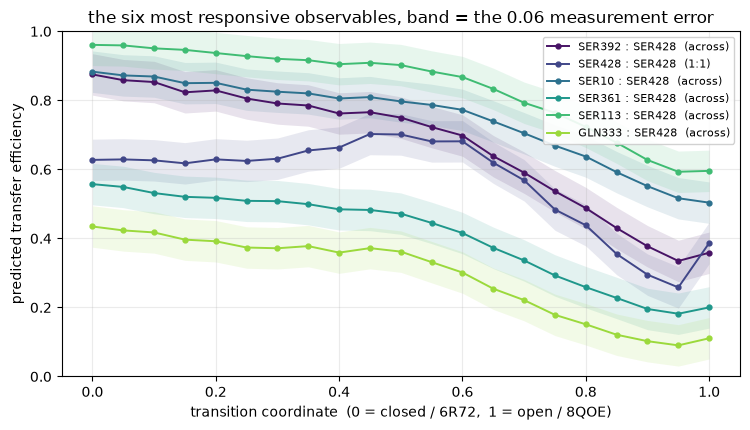

69 of 100 observables move by less than 2 x 0.06 across the whole transition; the widest moves by 0.54


In [8]:
span = observables.max(0) - observables.min(0)
best = np.argsort(-span)[:6]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
colours = plt.cm.viridis(np.linspace(0.05, 0.85, len(best)))
for colour, k in zip(colours, best):
    a, b, kind = keys[k]
    label = (f"{resname[('A', sites[a])]}{sites[a]} : "
             f"{resname[('A', sites[b])]}{sites[b]}  ({kind})")
    ax.plot(frac, observables[:, k], "o-", ms=3.5, lw=1.4, color=colour, label=label)
    ax.fill_between(frac, observables[:, k] - ERR, observables[:, k] + ERR,
                    color=colour, alpha=0.12, lw=0)
ax.set_xlabel("transition coordinate  (0 = closed / 6R72,  1 = open / 8QOE)")
ax.set_ylabel("predicted transfer efficiency")
ax.set_title(f"the six most responsive observables, band = the {ERR} measurement error")
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

flat = int((span < 2 * ERR).sum())
print(f"{flat} of {len(keys)} observables move by less than 2 x {ERR} across the "
      f"whole transition; the widest moves by {span.max():.2f}")

## 5. The selection

`select_probe_positions` is given the predicted efficiencies, the pairwise RMSD
between the assemblies, and `pair_sites` — the two site indices each observable
connects. That last array *is* the statement that this is a dimer: it is what
tells the selector that choosing sites *i* and *j* delivers their 1:1
distances, their within-protomer distance and their across-protomer distance,
all at once.

Each step reports the expected mean RMSD left between the true assembly and the
one the measurements would single out. The prior — the number with no data at
all — is printed first.

In [9]:
E = np.ascontiguousarray(observables)
chosen, decay = bff.select_probe_positions(E, rmsds, pair_sites,
                                           measurement_error=ERR, max_sites=6)
chosen, decay = np.asarray(chosen), np.asarray(decay)
prior = bff.expected_rmsd(rmsds.ravel(), np.zeros(rmsds.size), 1, 0.99, N_FRAMES)


def expected(subset):
    """Olga's criterion for an arbitrary set of sites: chi2 from every implied observable."""
    used = [k for k, key in enumerate(keys) if key[0] in subset and key[1] in subset]
    chi2 = np.zeros((N_FRAMES, N_FRAMES))
    for k in used:
        v = E[:, k]
        chi2 += (v[:, None] - v[None, :]) ** 2 / ERR ** 2
    return bff.expected_rmsd(rmsds.ravel(), chi2.ravel(), max(len(used), 1),
                             0.99, N_FRAMES), len(used)


print(f"prior, no data at all: {prior:.2f} A\n")
print(f"{'#':>2}  {'mutation':>10}  {'score':>5}  {'measures':>8}  "
      f"{'expected RMSD':>13}  {'change':>7}")
previous = prior
for rank, (s, value) in enumerate(zip(chosen, decay), start=1):
    _, n_measurements = expected(set(chosen[:rank].tolist()))
    print(f"{rank:>2}  {resname[('A', sites[s])] + str(sites[s]):>10}  "
          f"{ls_closed[('A', sites[s])]:>5.2f}  {n_measurements:>8}  "
          f"{value:>11.2f} A  {value - previous:>+6.2f} A")
    previous = value

prior, no data at all: 3.86 A

 #    mutation  score  measures  expected RMSD   change
 1       GLN66   1.72         1         1.28 A   -2.58 A
 2       SER10   1.70         4         1.40 A   +0.12 A
 3      SER428   1.81         9         1.40 A   +0.00 A
 4      SER143   1.62        16         1.50 A   +0.10 A
 5      SER392   1.70        25         1.59 A   +0.09 A
 6      SER235   1.62        36         1.61 A   +0.02 A


The first mutation does nearly all the work, and after that the curve stops
falling. That is not a failure of the code, it is what the ensemble is: a
**one-parameter** family. Every distance in it reports the same number — how far
the transition has gone — so once one measurement has pinned that number down,
the rest are repeating it.

And repeating it is not free. Olga's criterion weights the pairwise RMSDs by
the right-tail probability of the accumulated χ², and that probability is taken
at the degrees of freedom of the *whole* set. A redundant measurement adds a
degree of freedom without adding information, which widens the set of
assemblies that stay compatible with the data. So the expected RMSD can, and
here does, go back up. Read it as the criterion saying the experiment was over
after the first mutation.

That is worth taking seriously rather than tuning away, because it is the
honest answer to the question as posed: *telling BmrA's closed state from its
open state* is a one-parameter question, and one well-placed cysteine answers
it. A network of many sites is the right instrument for a harder question —
one where the candidate structures differ in more than one way.

### How good is the greedy answer?

Greedy takes the locally best site and never revisits it. With ten candidates,
every subset of up to four can be scored outright, so for once the greedy's
answer can be compared with the best one instead of trusted.

The comparison is not a formality here. The greedy's first step can only see
one measurement — a single site implies only its own 1:1 distance — so it picks
whichever site has the best 1:1 pair, and that site need not belong in the best
pair of sites at all.

In [10]:
print(f"{'k':>2}  {'best set':>26}  {'expected':>9}   "
      f"{'greedy set':>26}  {'expected':>9}")
exhaustive = []
for size in (1, 2, 3, 4):
    scored = sorted((expected(set(s))[0], [sites[x] for x in s])
                    for s in itertools.combinations(range(len(sites)), size))
    greedy_value, _ = expected(set(chosen[:size].tolist()))
    exhaustive.append(scored[0][0])
    print(f"{size:>2}  {str(scored[0][1]):>26}  {scored[0][0]:>7.2f} A   "
          f"{str([sites[x] for x in chosen[:size]]):>26}  {greedy_value:>7.2f} A")

 k                    best set   expected                   greedy set   expected
 1                        [66]     1.28 A                         [66]     1.28 A
 2                  [392, 428]     1.28 A                     [66, 10]     1.40 A
 3             [235, 392, 428]     1.29 A                [66, 10, 428]     1.40 A
 4        [235, 333, 392, 428]     1.39 A           [66, 10, 428, 143]     1.50 A


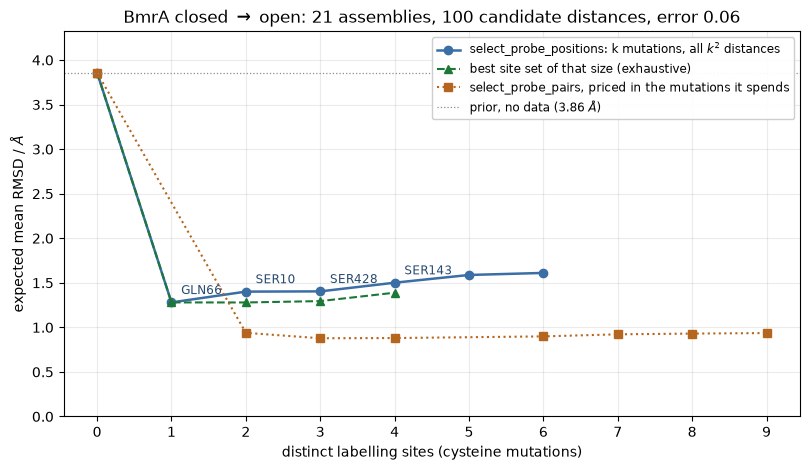

In [11]:
selected_pairs, pair_decay = bff.select_probe_pairs(E, rmsds, measurement_error=ERR,
                                                    max_pairs=10)
selected_pairs, pair_decay = np.asarray(selected_pairs), np.asarray(pair_decay)
seen, mutations = set(), []
for p in selected_pairs:
    seen.update(pair_sites[p].tolist())
    mutations.append(len(seen))

best_at = {}
for spent, value in zip(mutations, pair_decay):
    best_at[spent] = min(best_at.get(spent, np.inf), value)
pair_x = sorted(best_at)
pair_y = [best_at[x] for x in pair_x]

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(np.arange(0, len(decay) + 1), np.r_[prior, decay], "o-", color="#3b6ea5", lw=1.8,
        label="select_probe_positions: k mutations, all $k^2$ distances")
ax.plot(np.arange(0, len(exhaustive) + 1), np.r_[prior, exhaustive], "^--",
        color="#1b7837", lw=1.5, label="best site set of that size (exhaustive)")
ax.plot([0] + pair_x, [prior] + pair_y, "s:", color="#b5651d", lw=1.5,
        label="select_probe_pairs, priced in the mutations it spends")
ax.axhline(prior, color="0.55", lw=0.9, ls=":", label=f"prior, no data ({prior:.2f} $\\AA$)")
for rank, s in enumerate(chosen[:4], start=1):
    ax.annotate(f"{resname[('A', sites[s])]}{sites[s]}", (rank, decay[rank - 1]),
                textcoords="offset points", xytext=(7, 6), fontsize=8.5, color="#26496e")
ax.set_xlabel("distinct labelling sites (cysteine mutations)")
ax.set_ylabel("expected mean RMSD / $\\AA$")
ax.set_title(f"BmrA closed $\\to$ open: {N_FRAMES} assemblies, "
             f"{len(keys)} candidate distances, error {ERR}")
ax.set_xticks(np.arange(0, max(len(decay), max(mutations)) + 1))
ax.set_ylim(0.0, prior * 1.12)
ax.legend(fontsize=8.5, loc="upper right", framealpha=0.95)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 6. What the pair selector would have said, and why you cannot buy it

`select_probe_pairs` is the monomer selector. Given the same columns it picks
the single most informative distance and reports a much lower expected RMSD for
it — the orange curve above sits below the blue one over most of the range.

That number is not purchasable on a homodimer. The pair it picks is a distance
between two sites, and getting it means mutating both; and the moment both are
mutated, the sample also contains the 1:1 distance of each site and the other
combination of the two. There is no construct that delivers the one distance
and not the rest. The blue curve is what those mutations actually buy, priced
with everything that comes in the same tube.

The listing below makes the accounting explicit: the pair, the kind of
measurement it is, and how many distinct mutations have been spent by the time
the selector has asked for it.

In [12]:
print(f"{'#':>2}  {'pair':>24}  {'kind':>14}  {'mutations':>9}  {'expected RMSD':>13}")
for rank, (p, spent, value) in enumerate(zip(selected_pairs, mutations, pair_decay), start=1):
    a, b, kind = keys[p]
    label = f"{resname[('A', sites[a])]}{sites[a]} : {resname[('A', sites[b])]}{sites[b]}"
    print(f"{rank:>2}  {label:>24}  {kind:>14}  {spent:>9}  {value:>11.2f} A")

first = set(pair_sites[selected_pairs[0]].tolist())
site_value, site_measurements = expected(first)
print(f"\nthe pair selector's first pick spends {mutations[0]} mutations on "
      + " and ".join(f"{resname[('A', sites[s])]}{sites[s]}" for s in sorted(first))
      + f" and quotes {pair_decay[0]:.2f} A for that one distance")
print(f"those same mutations deliver {site_measurements} distances, not one; priced "
      f"with all of them the expected RMSD is {site_value:.2f} A")

 #                      pair            kind  mutations  expected RMSD
 1           SER392 : SER428          across          2         0.94 A
 2           SER235 : SER392    one protomer          3         0.88 A
 3             GLN66 : GLN66             1:1          4         0.88 A
 4           SER428 : SER428             1:1          4         0.90 A
 5           SER113 : GLN333          across          6         0.90 A
 6           SER113 : SER235    one protomer          6         0.91 A
 7            SER10 : SER428          across          7         0.92 A
 8           SER143 : SER428    one protomer          8         0.93 A
 9           SER361 : SER428          across          9         0.94 A
10           SER143 : SER428          across          9         0.95 A

the pair selector's first pick spends 2 mutations on SER392 and SER428 and quotes 0.94 A for that one distance
those same mutations deliver 4 distances, not one; priced with all of them the expected RMSD is 1.28 A


## 7. How many mutations you need is a property of your precision

Nothing above says a homodimer experiment needs one site. It says *this*
question, at *this* measurement error, does. Degrade the precision and the
first measurement no longer settles the transition coordinate on its own, and a
second site starts to pay — which is the regime where choosing a *set* is the
whole problem, and where the site selector earns its keep.

The sweep below recomputes the best one-, two- and three-site sets over a range
of measurement errors. It is the same criterion and the same predicted
efficiencies; only the error changes. "Pays" needs a line drawn somewhere, so
it is drawn at five per cent of the expected RMSD; a gain smaller than that is
not worth a mutation and, at this ensemble size, is not larger than the scatter
of the volume calculation either.

Watch the third site: it never clears that line anywhere in the range. One
measurement of a one-parameter family is already close to all the information
there is, and past that point extra distances mostly add degrees of freedom.

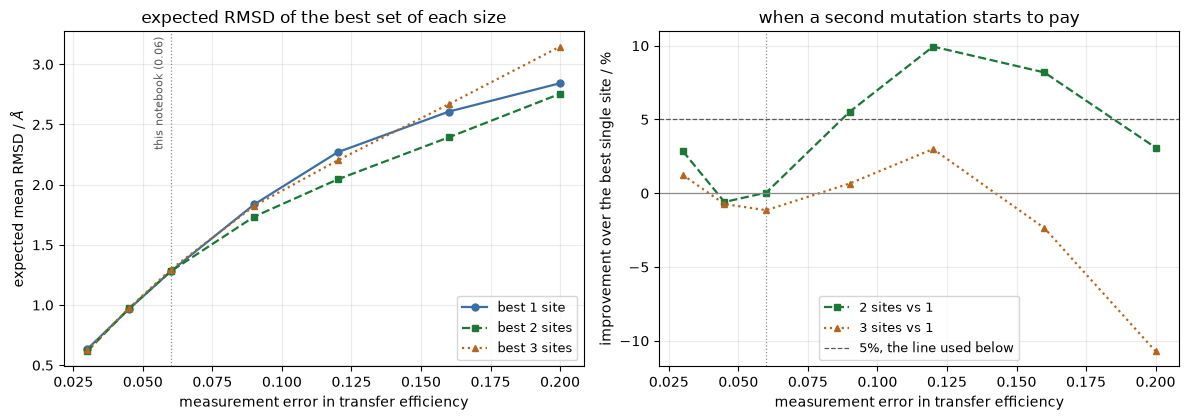

error 0.030: best single site 0.63 A, best pair of sites 0.62 A, +2.9%   -> one site is enough
error 0.045: best single site 0.97 A, best pair of sites 0.97 A, -0.6%   -> one site is enough
error 0.060: best single site 1.28 A, best pair of sites 1.28 A, +0.0%   -> one site is enough
error 0.090: best single site 1.84 A, best pair of sites 1.73 A, +5.5%   -> a second site pays
error 0.120: best single site 2.27 A, best pair of sites 2.04 A, +9.9%   -> a second site pays
error 0.160: best single site 2.61 A, best pair of sites 2.39 A, +8.2%   -> a second site pays
error 0.200: best single site 2.84 A, best pair of sites 2.75 A, +3.1%   -> one site is enough


In [13]:
errors = np.array([0.03, 0.045, 0.06, 0.09, 0.12, 0.16, 0.20])


def expected_at(subset, err):
    used = [k for k, key in enumerate(keys) if key[0] in subset and key[1] in subset]
    chi2 = np.zeros((N_FRAMES, N_FRAMES))
    for k in used:
        v = E[:, k]
        chi2 += (v[:, None] - v[None, :]) ** 2 / err ** 2
    return bff.expected_rmsd(rmsds.ravel(), chi2.ravel(), max(len(used), 1), 0.99, N_FRAMES)


curves = {size: [min(expected_at(set(s), err)
                     for s in itertools.combinations(range(len(sites)), size))
                 for err in errors] for size in (1, 2, 3)}

PAYS = 0.05   # a further mutation "pays" if it buys at least 5 % of the expected RMSD

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12.0, 4.3))
for size, style, colour in ((1, "o-", "#3b6ea5"), (2, "s--", "#1b7837"), (3, "^:", "#b5651d")):
    ax.plot(errors, curves[size], style, color=colour, lw=1.6, ms=5,
            label=f"best {size} site" + ("s" if size > 1 else ""))
ax.axvline(ERR, color="0.55", lw=0.9, ls=":")
ax.annotate(f"this notebook ({ERR})", (ERR, ax.get_ylim()[1]), fontsize=8, color="0.35",
            rotation=90, va="top", ha="right", xytext=(-4, -4), textcoords="offset points")
ax.set_xlabel("measurement error in transfer efficiency")
ax.set_ylabel("expected mean RMSD / $\\AA$")
ax.set_title("expected RMSD of the best set of each size")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

one = np.array(curves[1])
for size, style, colour in ((2, "s--", "#1b7837"), (3, "^:", "#b5651d")):
    bx.plot(errors, 100.0 * (one - np.array(curves[size])) / one, style, color=colour,
            lw=1.6, ms=5, label=f"{size} sites vs 1")
bx.axhline(0.0, color="0.55", lw=0.9)
bx.axhline(100 * PAYS, color="0.35", lw=0.9, ls="--",
           label=f"{PAYS:.0%}, the line used below")
bx.axvline(ERR, color="0.55", lw=0.9, ls=":")
bx.set_xlabel("measurement error in transfer efficiency")
bx.set_ylabel("improvement over the best single site / %")
bx.set_title("when a second mutation starts to pay")
bx.legend(fontsize=9)
bx.grid(alpha=0.25)
fig.tight_layout()
plt.show()

for err, single, double in zip(errors, curves[1], curves[2]):
    gain = (single - double) / single
    verdict = "a second site pays" if gain >= PAYS else "one site is enough"
    print(f"error {err:.3f}: best single site {single:.2f} A, best pair of sites "
          f"{double:.2f} A, {gain:+.1%}   -> {verdict}")

## 8. Where the chosen sites are

The clouds below are accessible volumes of the selected sites, computed on the
same two structures and with the same linker geometry the distances used, by
`workshop.av`. (It draws on a coarser grid than the tables were computed on,
which changes how the surface looks and not where the dye can go.) The left
panel is the closed dimer, the right the open one, and each site appears on
both protomers — which is what "one mutation, two labels" looks like.

The view needs Mol\* from a CDN and therefore internet access from the browser.
Nothing else in the notebook depends on it.

In [14]:
palette = [0x3B6EA5, 0xB5651D, 0x1B7837, 0x7B3294]
shown, panels = [], []
for rank, s in enumerate(chosen[:3]):
    shown.append({"chain": "A", "resi": sites[s], "colour": palette[rank % len(palette)]})
    shown.append({"chain": "B", "resi": sites[s], "colour": palette[rank % len(palette)]})
legend = ", ".join(f"{resname[('A', sites[s])]}{sites[s]}" for s in chosen[:3])
for state, path in (("closed", pdb_closed), ("open", pdb_open)):
    try:
        panels.append(ws.site_panel(state, shown, pdb_path=path,
                                    title=f"BmrA {state} -- {legend}"))
    except ws.EmptyVolume as problem:
        print(problem)
if panels:
    ws.show(panels, height=460)
print("sites drawn:", legend, "(the first three the selector asked for, both protomers)")

sites drawn: GLN66, SER10, SER428 (the first three the selector asked for, both protomers)


## 9. Trimers, tetramers, and what does not change

The selector does not know the oligomer order — `pair_sites` is the whole model
of it. A trimer offers, per pair of sites, the protomer pairs A:B, A:C and B:C
as well as the within-protomer distance; a tetramer six protomer pairs; a
C*n*-symmetric assembly collapses some of those onto each other for as long as
it really is symmetric, which is what the check in section 4 measures. The
arithmetic — score a candidate site by every distance the enlarged set implies
— is the same code path throughout. The monomer is the special case where each
site owns exactly one pair, and there `select_probe_positions` and
`select_probe_pairs` agree exactly; that agreement is pinned in
`test/restraints/test_greedy_sites.py`.

Three things this notebook is honest about, and that carry over to any
homo-oligomer:

1. **The conservation term is missing.** BmrA has no ConSurf grades from any of
   the usual sources, so the label score here is local geometry and chemistry
   only. It cannot tell a well-behaved surface serine from a well-behaved
   surface serine that happens to be functionally important. Whatever the
   selection returns still has to be read against the annotation.
2. **The ensemble is a straight line between two deposited states.** It is a
   ruler, not a pathway, and the answer it gives is the answer to a
   one-parameter question. A planning ensemble that has to discriminate
   docking arrangements, or several conformations at once, will not saturate
   after one mutation — and that is the case where choosing a *set* of sites is
   the real problem.
3. **Greedy is myopic, and here you can see it.** The first step sees only 1:1
   distances, so it optimises the wrong thing, and the exhaustive comparison in
   section 5 shows by how much. Where the candidate list is short enough to
   enumerate, enumerate. Where it is not, the decay curve is the guard: where
   it flattens, another mutation has stopped paying.